# 🌲 Random Forest (Classification + Regression)



---

## What is an Ensemble Method?

An ensemble method is a machine learning technique that combines several base models in order to produce one optimal predictive model.

### 🧠 Think About It

**Q:** If you have a complex medical issue, do you ask just one doctor, or do you get a second (and third) opinion?

### ✅ Answer

You get multiple opinions! If one doctor makes a mistake, the others can correct it. **This is the exact intuition behind Ensemble Methods.** We combine many weak/average models to create one super-model.

## The "Board of Directors" Method (Bagging)

Random Forest uses a technique called **Bagging (Bootstrap Aggregating)**.

1. **Bootstrap (The Data):** We create many different random sub-samples of our training data (with replacement).
2. **Aggregating (The Vote):** We train a single Decision Tree on *each* random sample. Then, to make a final prediction, we let all the trees vote (Classification = Majority Vote // Regression = Average).

**Example:** Imagine a company's Board of Directors. 100 directors (trees) each look at a slightly different subset of company data. They all make a prediction, and the CEO takes the majority vote. This is much safer than relying on 1 rogue director!

## 0) Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
)
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score,
    accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.datasets import load_breast_cancer, fetch_california_housing, make_classification

# ---------------------------------------------------------
# Plotting Aesthetics and Reproducibility
# ---------------------------------------------------------
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Setting a global random seed so you get the exact 
# same outputs on your machines.
RSEED = 42
np.random.seed(RSEED)

### Helper Functions
These helpers keep our code cells clean by hiding the matplotlib boilerplate.

In [12]:
def top_k_bar(series: pd.Series, k: int = 15, title: str = "Top features"):
    """Helper to visually plot the top N most important features in a bar chart."""
    s = series.sort_values(ascending=False).head(k)[::-1]
    ax = s.plot(kind="barh")
    ax.set_title(title)
    ax.set_xlabel(series.name if series.name else "importance")
    plt.tight_layout()
    return ax

def regression_report(y_true, y_pred, prefix: str = ""):
    """Returns the 3 most common regression metrics as a dictionary."""
    rmse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        f"{prefix}RMSE": rmse,
        f"{prefix}MAE": mae,
        f"{prefix}R2": r2,
    }

---

## 1) Random Forest for Classification

We’ll use **Breast Cancer Wisconsin (Diagnostic)**. This is a binary classification dataset (predicting if a tumor is malignant or benign based on cell nuclei measurements).

In [3]:
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

print("X shape:", X.shape)
print("Class balance:\n", y.value_counts(normalize=True).rename("fraction"))

# Split the data into 80% training / 20% validation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RSEED, stratify=y
)

X shape: (569, 30)
Class balance:
 target
1    0.627417
0    0.372583
Name: fraction, dtype: float64


In [10]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [11]:
y

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: target, Length: 569, dtype: int64

### 1.1 Training the Baseline Random Forest

The "Random" in Random Forest comes from two places:
1. Random rows of data (Bootstrap)
2. Random columns (Features) chosen at each split!

---

### 🧠 Think About It

**Q:** Why don't we just give *every* tree *all* the features? Wouldn't they make better decisions?

### ✅ Answer

If every tree saw all the features, and one feature was incredibly strong (like tumor size), almost every tree would just split on tumor size first! 

We would end up with 100 identical trees. That defeats the purpose of an ensemble! By forcing the trees to look at random subsets of features (`max_features="sqrt"`), we force them to learn different patterns. This **decorrelates** the trees and creates a robust "Board of Directors".

In [4]:
# Initialize the Random Forest Classifier
rf_clf = RandomForestClassifier(
    n_estimators=400,          # 1. How many trees in our "Board of Directors"?
    max_features="sqrt",       # 2. Force diversity: each tree only sees a random subset of features per split
    oob_score=True,            # 3. Built-in validation: evaluate trees on the 1/3 of data they didn't train on
    random_state=RSEED,        # 4. Consistency for reproducibility
    n_jobs=-1                  # 5. Use all CPU cores to train the 400 trees in parallel at lightning speed!
)

# Fit the model (all 400 trees are built here)
rf_clf.fit(X_train, y_train)

# Gather Predictions & Probabilities
y_pred = rf_clf.predict(X_test)
y_proba = rf_clf.predict_proba(X_test)[:, 1] # Probability of being class "1" (Benign)

print("Test accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Test F1:", round(f1_score(y_test, y_pred), 4))
print("Test ROC AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("\nOOB Score:", round(rf_clf.oob_score_, 4))

Test accuracy: 0.9561
Test F1: 0.9655
Test ROC AUC: 0.9934

OOB Score: 0.9604


### 🧠 Think About It: What is the OOB Score?

**Q:** What does `oob_score_` mean and why is it so close to our test accuracy?

### ✅ Answer

When we create "Bootstrap" samples (random rows with replacement), about **1/3 of the data is left out** of each tree's training set. These left-out rows are "Out-Of-Bag" (OOB).

The model automatically tests each tree on the rows it didn't see during training. It's essentially a **free cross-validation** built right into the Random Forest algorithm!

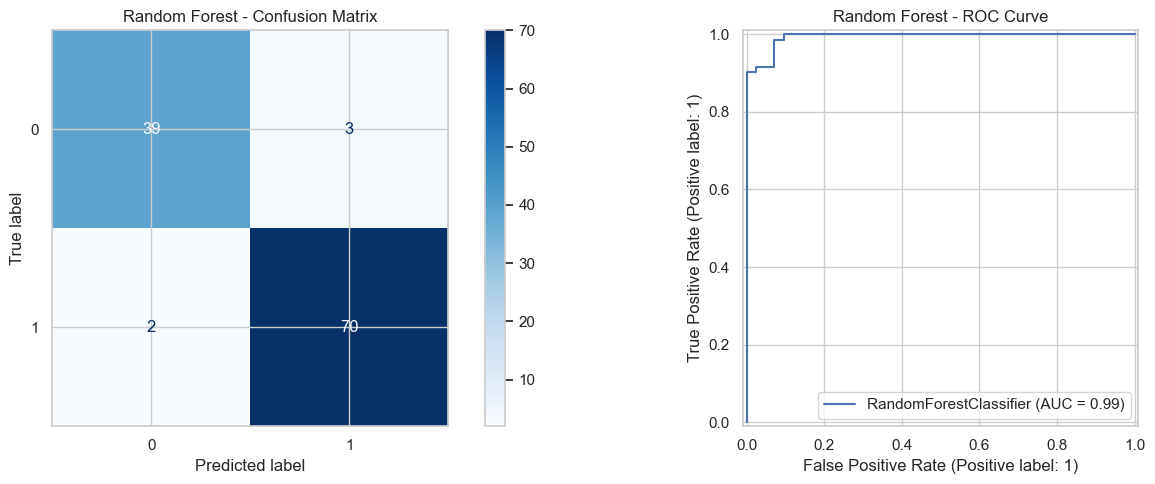

In [5]:
# Plotting the Confusion Matrix & ROC curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ConfusionMatrixDisplay.from_estimator(rf_clf, X_test, y_test, cmap="Blues", ax=ax1)
ax1.set_title("Random Forest - Confusion Matrix")

RocCurveDisplay.from_estimator(rf_clf, X_test, y_test, ax=ax2)
ax2.set_title("Random Forest - ROC Curve")

plt.tight_layout()
plt.show()

---
## 1.2 Feature Importance (Impress Your Interviewer)

One of the best things about Random Forest is that it tells us *which features were most useful*.

There are two ways to calculate this:
1. **Gini (Impurity) Importance:** Fast, built-in (`feature_importances_`), but can be biased toward continuous features with many unique values.
2. **Permutation Importance:** Slower, but measures the actual drop in accuracy if we scramble a feature. Much safer for explanations!

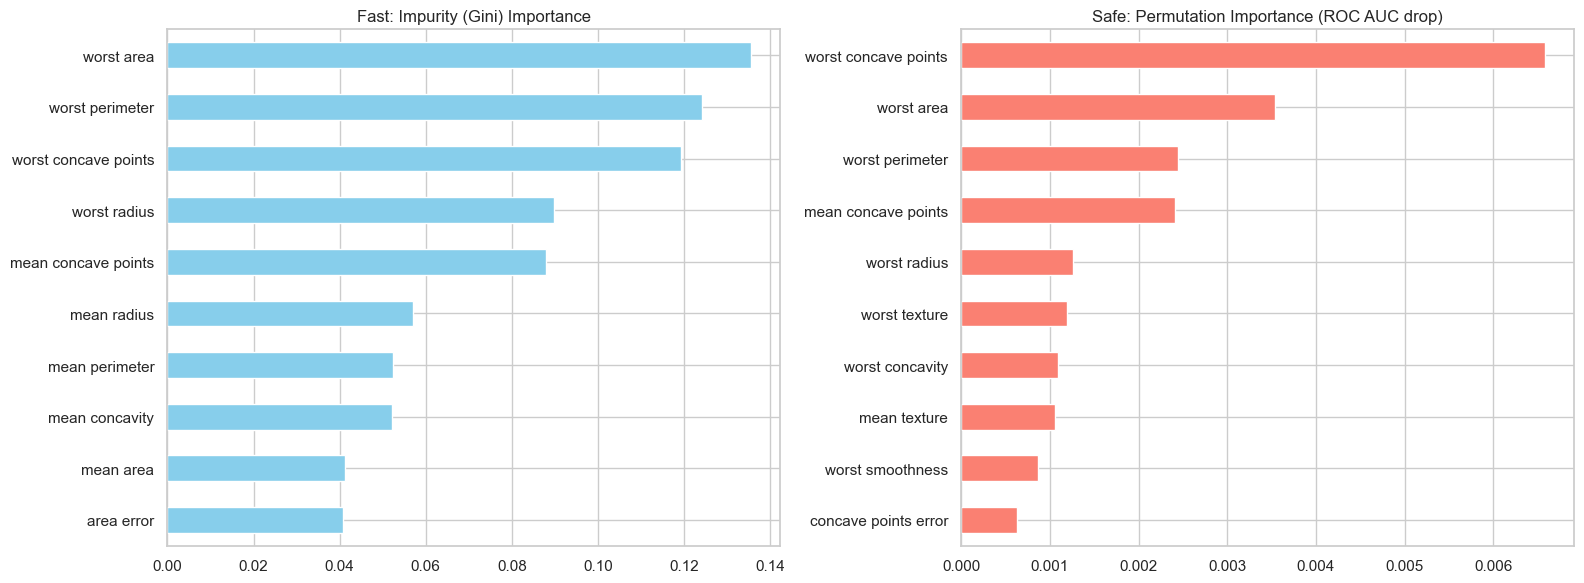

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Gini Importance (The mathematically fast, built-in way)
imp_gini = pd.Series(rf_clf.feature_importances_, index=X.columns, name="Gini Drop")
s_gini = imp_gini.sort_values(ascending=False).head(10)[::-1]
s_gini.plot(kind="barh", ax=ax1, color='skyblue')
ax1.set_title("Fast: Impurity (Gini) Importance")

# 2. Permutation Importance (The safe, "shuffle-and-test" method)
# 'n_repeats=5' means we shuffle each column 5 times to see how hard the "roc_auc" score crashes.
perm = permutation_importance(
    rf_clf, X_test, y_test, n_repeats=5, random_state=RSEED, n_jobs=-1, scoring="roc_auc"
)
perm_imp = pd.Series(perm.importances_mean, index=X.columns, name="AUC Drop")
s_perm = perm_imp.sort_values(ascending=False).head(10)[::-1]
s_perm.plot(kind="barh", ax=ax2, color='salmon')
ax2.set_title("Safe: Permutation Importance (ROC AUC drop)")

plt.tight_layout()
plt.show()

---
## 1.3 Hyperparameter Tuning

### 🧠 Think About It
**Q:** Decision trees are prone to severe overfitting (memorizing the data). How do we stop the 400 trees in our Random Forest from overfitting?

### ✅ Answer
By restricting how deep they can grow! We tune parameters like `max_depth` (limit the height) and `min_samples_leaf` (require a certain number of samples to make a final splitting decision).

In [7]:
# We use StratifiedKFold to keep the benign/malignant ratio balanced in all 5 folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RSEED)

# The parameters we want to test:
param_distributions = {
    "n_estimators": [200, 400],           # Tree count
    "max_depth": [None, 4, 10],           # Hard limit on tree height (stops overfitting)
    "min_samples_leaf": [1, 2, 8],        # Leaves with < N samples are forbidden
    "max_features": ["sqrt", 0.5],        # Percentage of features seen simultaneously
}

# RandomizedSearchCV is vastly faster than GridSearch
search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RSEED, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=5,             # Just 5 random parameter combinations for execution speed
    scoring="roc_auc",    # We optimize for AUC, not sheer accuracy
    cv=cv,
    random_state=RSEED,
    n_jobs=-1,
)

search.fit(X_train, y_train)
print("Best CV ROC AUC:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

Best CV ROC AUC: 0.9911
Best params: {'n_estimators': 400, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 4}


---
## 2) Random Forest for Regression

We can use the exact same logic for Regression. 

Instead of taking a "majority vote" of classes (e.g. 80 trees say Malignant, 20 say Benign -> Predict Malignant), the trees **average their continuous predictions** (e.g., Tree 1 predicts house costs $400k, Tree 2 predicts $450k... final prediction = average).

In [8]:
dataset_name = None
try:
    housing = fetch_california_housing(as_frame=True)
    Xr = housing.data
    yr = housing.target
    dataset_name = "California Housing ($100k units)"
except Exception as e:
    # Fallback to a built-in dataset if an internet connection is unavailable 
    from sklearn.datasets import load_diabetes
    diab = load_diabetes(as_frame=True)
    Xr = diab.data
    yr = diab.target
    dataset_name = "Diabetes (fallback)"

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.2, random_state=RSEED
)

print("Dataset used:", dataset_name)
Xr.head(3)

Dataset used: California Housing ($100k units)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24


In [14]:
# Initialize the Regressor (Warning: it's not a Classifier anymore!)
rf_reg = RandomForestRegressor(
    n_estimators=100,
    max_features=0.7,      # 70% of features used at each split
    random_state=RSEED,
    n_jobs=-1
)

rf_reg.fit(Xr_train, yr_train)

# Evaluate
yr_pred = rf_reg.predict(Xr_test)
pd.Series(regression_report(yr_test, yr_pred)).to_frame("Metric Value")

,Metric Value
RMSE,0.251495
MAE,0.325886
R2,0.808079


### 🧠 Think About It (Crucial for Interviews)

**Q:** If the highest priced house in our training data is $500,000... is it geometrically possible for a Random Forest to predict a new house costs $600,000?

### ✅ Answer
**NO!** A Random Forest can *never extrapolate* beyond the range of the training data. The trees are simply finding the average of the leaf nodes. They cannot project a linear equation into infinity like Linear Regression can. If predicting future extreme trends (like next year's record-high stock market), Random Forests fail completely.